# British Airways Reviews Analysis

This notebook analyzes reviews of British Airways. The analysis includes web scraping, data cleaning, sentiment analysis, and topic modeling.

## Step 1: Web Scraping

In this step, we will scrape reviews from the AirlineQuality.com website for British Airways. The data we collect will include:

- Review Title
- Rating
- Date Published
- Author
- Review Body
- Aircraft
- Route
- Seat Type
- Flight Date
- Various ratings (e.g., seat comfort, cabin staff service)

The scraped data will be saved into a CSV file foluding sentiment trends, common topics, and specific areas of improvement.


In [26]:
import requests
from bs4 import BeautifulSoup
import csv
import pandas as pd
import spacy
import re
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# Initialize spaCy model for lemmatization
nlp = spacy.load('en_core_web_sm')

# Initialize Porter Stemmer
stemmer = PorterStemmer()

# Define stopwords
stop_words = set(stopwords.words('english'))

# Function to preprocess text
def preprocess_text(text):
    # Tokenization and Lemmatization using spaCy
    doc = nlp(text.lower())  # Convert text to lowercase
    tokens = [token.text for token in doc if token.text not in stop_words and token.is_alpha]

    # Lemmatization and Stemming
    lemmatized_tokens = [token.lemma_ for token in doc if token.text not in stop_words and token.is_alpha]
    stemmed_tokens = [stemmer.stem(token) for token in lemmatized_tokens]

    # Join tokens back to string
    processed_text = ' '.join(stemmed_tokens)
    return processed_text


In [23]:
# Step 1: Scrape the reviews from the website
url = 'https://www.airlinequality.com/airline-reviews/british-airways/'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Open CSV file for writing
with open('ba_reviews.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    
    # Write the header row in the CSV
    writer.writerow(['Review Title', 'Rating', 'Date Published', 'Author', 'Review Body', 'Aircraft', 'Route', 'Seat Type', 'Flight Date', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Ground Service', 'Value For Money', 'Recommended'])
    
    # Find all the review articles
    reviews = soup.find_all('article', class_='comp_media-review-rated')

    for review in reviews:
        try:
            # Extract review details
            title = review.find('h2', class_='text_header').text.strip()
            rating_value = review.find('span', itemprop='ratingValue').text.strip()
            date_published = review.find('time', itemprop='datePublished').text.strip()
            author = review.find('span', itemprop='name').text.strip()
            review_body = review.find('div', itemprop='reviewBody').text.strip()
            aircraft = review.find('td', class_='review-rating-header aircraft').find_next_sibling('td').text.strip()
            route = review.find('td', class_='review-rating-header route').find_next_sibling('td').text.strip()
            seat_type = review.find('td', class_='review-rating-header cabin_flown').find_next_sibling('td').text.strip()
            flight_date = review.find('td', class_='review-rating-header date_flown').find_next_sibling('td').text.strip()
            seat_comfort = review.find('td', class_='review-rating-header seat_comfort').find_next_sibling('td').text.strip()
            cabin_staff_service = review.find('td', class_='review-rating-header cabin_staff_service').find_next_sibling('td').text.strip()
            food_and_beverages = review.find('td', class_='review-rating-header food_and_beverages').find_next_sibling('td').text.strip()
            ground_service = review.find('td', class_='review-rating-header ground_service').find_next_sibling('td').text.strip()
            value_for_money = review.find('td', class_='review-rating-header value_for_money').find_next_sibling('td').text.strip()
            recommended = review.find('td', class_='review-rating-header recommended').find_next_sibling('td').text.strip()

            # Write the data to the CSV file
            writer.writerow([title, rating_value, date_published, author, review_body, aircraft, route, seat_type, flight_date, seat_comfort, cabin_staff_service, food_and_beverages, ground_service, value_for_money, recommended])

        except AttributeError:
            continue

print("Reviews have been saved to 'ba_reviews.csv'")

Reviews have been saved to 'ba_reviews.csv'


 further analysis.

## Step 2: Data Cleaning

After scraping the reviews, we clean the data by performing the following tasks:

1. Removing rows with missing or incomplete data.
2. Stripping leading and trailing whitespaces from text columns.
3. Removing duplicate reviews.
4. Optionally removing special characters or unwanted words in the review bodies.

The cleaned data will theluding sentiment trends, common topics, and specific areas of improvement.


In [6]:
# Step 2: Load the CSV data and clean it
df = pd.read_csv('ba_reviews.csv')

# Remove rows with missing critical columns
df.dropna(subset=['Review Title', 'Rating', 'Review Body'], inplace=True)

# Strip whitespaces
df['Review Title'] = df['Review Title'].str.strip()
df['Review Body'] = df['Review Body'].str.strip()

# Remove duplicates
df.drop_duplicates(subset=['Review Title', 'Review Body'], inplace=True)

# Remove special characters from the review body
df['Review Body'] = df['Review Body'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# Check the cleaned data
df.head()

# Save the cleaned data
df.to_csv('cleaned_ba_reviews.csv', index=False)

print("Data cleaned and saved to 'cleaned_ba_reviews.csv'")

Data cleaned and saved to 'cleaned_ba_reviews.csv'



## Step 3: Sentiment Analysis

In this step, we will analyze the sentiment of each review. We will use the **VADER Sentiment Analysis** tool, which provides a compound score representing the overall sentiment of each review.

- Positive sentiment will have a score close to +1.
- Negative sentiment will have a score close to -1.
- Neutral sentiment will have a score close to 0.

We will apply sentiment analysis to the review bodies and save the sentiment results to a new CSV file.


Sentiment analysis complete and saved.


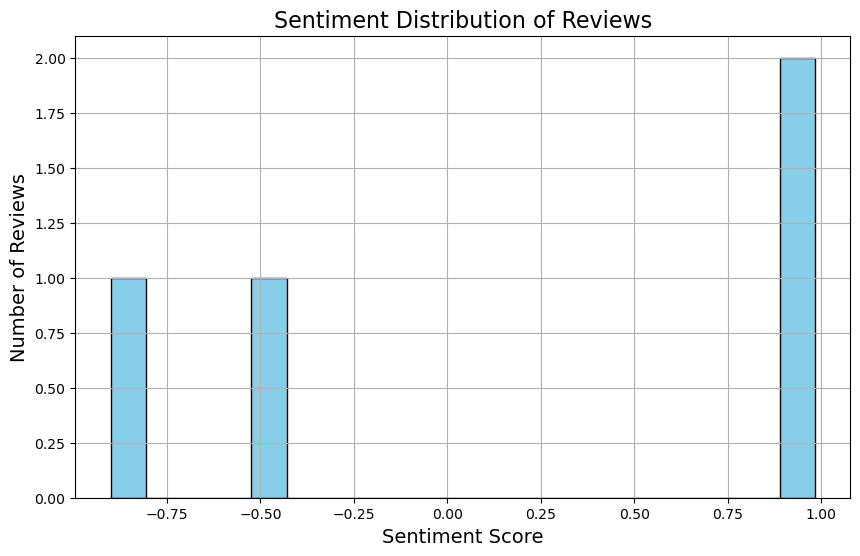

In [8]:
# Step 3: Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

# Function to get the sentiment polarity of the review body
def get_sentiment(text):
    sentiment = analyzer.polarity_scores(text)
    return sentiment['compound']  # Compound score for overall sentiment

# Apply sentiment analysis
df['Sentiment'] = df['Review Body'].apply(get_sentiment)

# Check sentiment distribution
df['Sentiment'].describe()

# Save sentiment data to a new CSV file
df.to_csv('with_sentiment_ba_reviews.csv', index=False)

print("Sentiment analysis complete and saved.")

plt.figure(figsize=(10, 6))
plt.hist(df['Sentiment'], bins=20, color='skyblue', edgecolor='black')
plt.title("Sentiment Distribution of Reviews", fontsize=16)
plt.xlabel("Sentiment Score", fontsize=14)
plt.ylabel("Number of Reviews", fontsize=14)
plt.grid(True)
plt.show()



## Step 4: Visualizing Review Data with Word Clouds

Next, we will visualize the most frequent words used in the reviews. A word cloud will be generated to highlight the most common words across all reviews. This helps us identify the key topics and themes that appear in customer feedback.

We will use the **WordCloud** library to generate the word cloud and **Matplotlib** for displaying it.



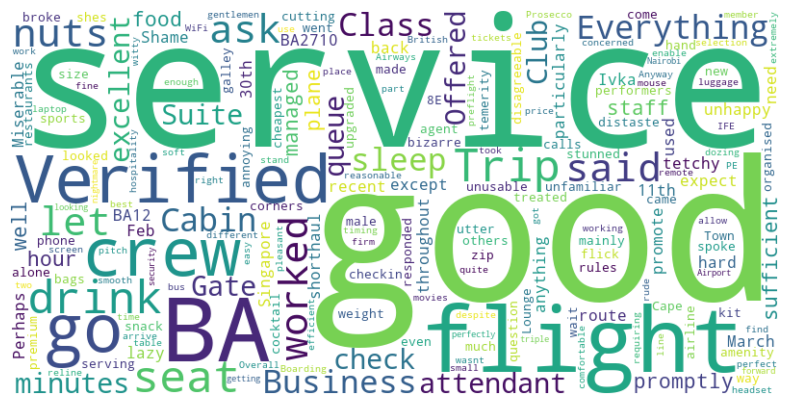

In [48]:
# Step 4: Generate a word cloud
all_reviews = ' '.join(df['Review Body'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
plt.savefig('wordcloud.png')  # Save the figure as a .png file
plt.close()

## Step 5: Topic Modeling with LDA

Topic modeling will allow us to identify underlying themes in the reviews. We will use **Latent Dirichlet Allocation (LDA)** to discover topics based on the text data.

LDA works by identifying groups of words that frequently occur together in documents, and from these groups, it defines topics. We will use the **CountVectorizer** to transform the text data into a bag-of-words format and apply LDA to uncover topics.

For each topic, we will display the top 10 words that best represent that topic.


Topic 1:
['worked', 'good', 'verified', 'service', 'ba', 'cabin', 'food', 'managed', 'offered', 'crew']

Topic 2:
['ba', 'crew', 'flight', 'worked', 'cabin', 'class', 'sleep', 'business', 'verified', 'ba2710']

Topic 3:
['good', 'service', 'flight', 'ask', 'nuts', 'seat', 'ba', 'said', 'let', 'promptly']

Topic 4:
['worked', 'good', 'verified', 'service', 'ba', 'cabin', 'food', 'managed', 'offered', 'crew']

Topic 5:
['trip', 'drink', 'verified', 'sufficient', 'crew', 'email', 'positive', 'chance', 'prior', 'getting']



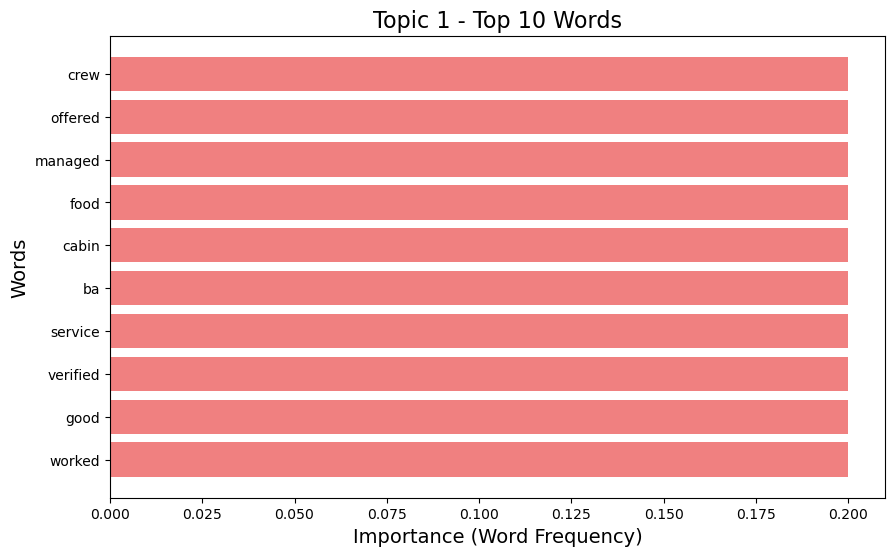

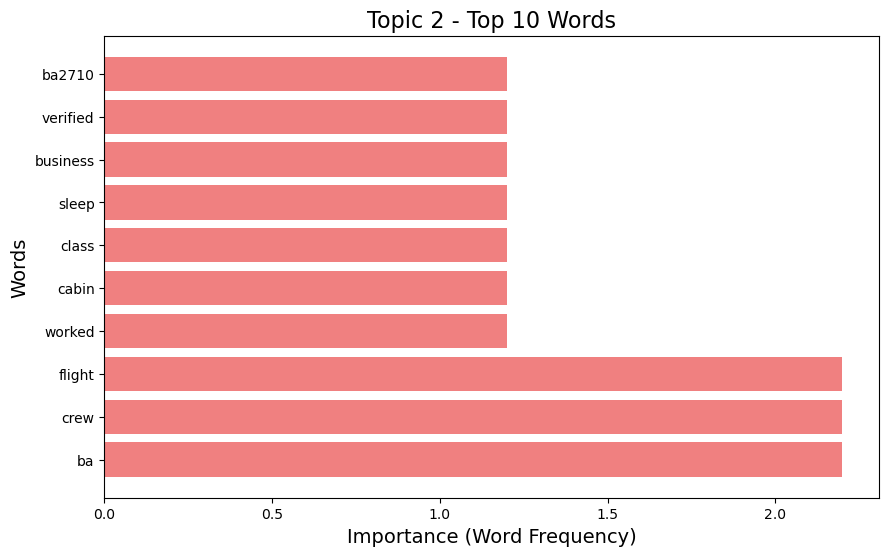

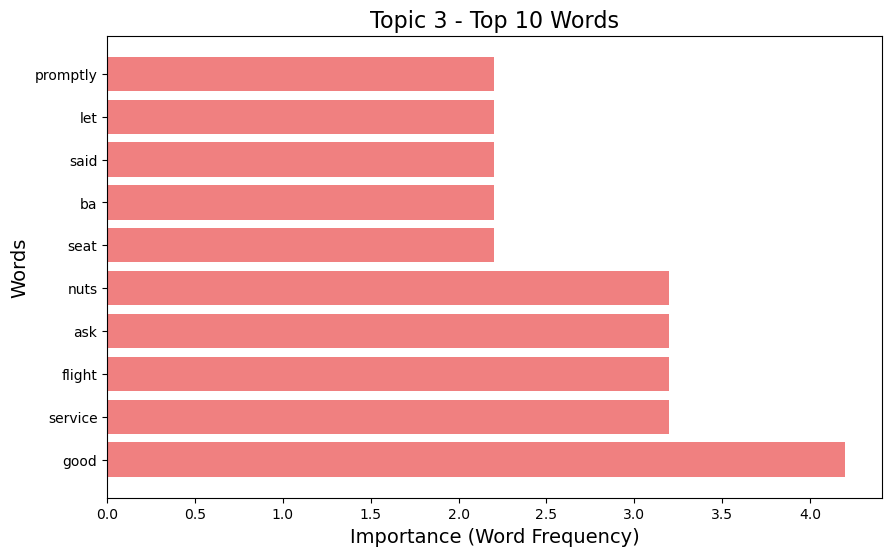

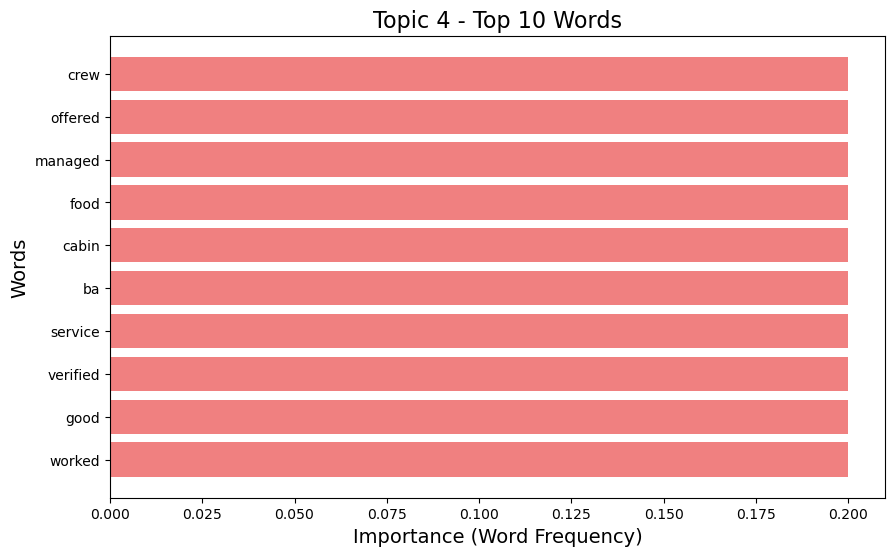

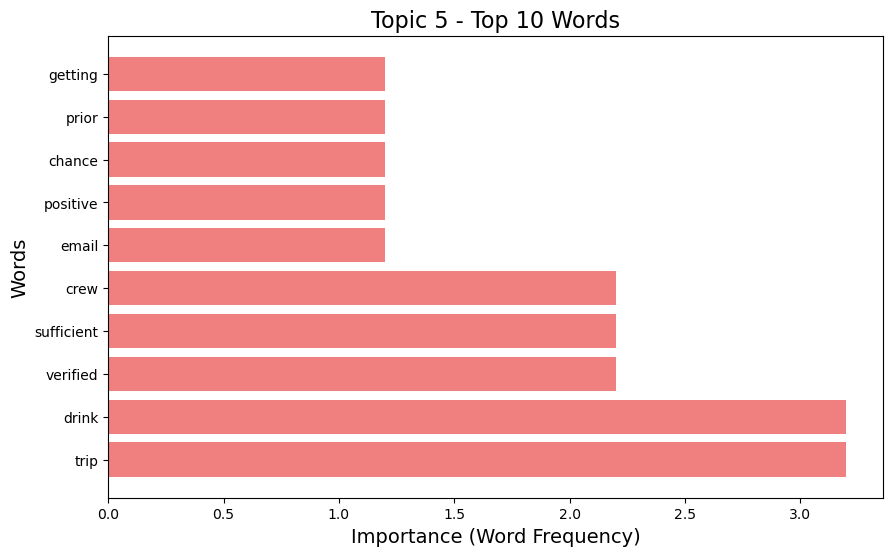

In [51]:

# Step 5: Topic Modeling with LDA
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Review Body'].dropna())

# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Display the topics
n_words = 10
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx + 1}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-n_words - 1:-1]])
    print()

n_topics = 5  # number of topics
n_words = 10  # number of words to show for each topic

# Plotting the top words for each topic
for idx, topic in enumerate(lda.components_):
    top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-n_words - 1:-1]]
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_words, topic[topic.argsort()[:-n_words - 1:-1]], color='lightcoral')
    plt.title(f"Topic {idx + 1} - Top {n_words} Words", fontsize=16)
    plt.xlabel('Importance (Word Frequency)', fontsize=14)
    plt.ylabel('Words', fontsize=14)
    plt.show()

plt.savefig('plot_image1.png')  # Save the figure as a .png file
plt.close()


## Step 6: Tokenization, Lemmatization, Stopword Removal, and Stemming

Before applying sentiment analysis and topic modeling, we will preprocess the text. The preprocessing steps include:

1. **Tokenization**: Breaking the text into individual words.
2. **Lemmatization**: Reducing words to their base or root form (e.g., "running" to "run").
3. **Stopword Removal**: Removing common words that do not contribute to the meaning of the text (e.g., "the", "and").
4. **Stemming**: Reducing words to their stem form (e.g., "running" to "run").

These steps help in improving the quality of text data for sentiment analysis and topic modeling.



In [36]:
# Step 6: Tokenization, Lemmatization, Stopword Removal, Stemming
df['Processed Review'] = df['Review Body'].apply(preprocess_text)

# Check the processed reviews
print(df[['Review Body', 'Processed Review']].head())

# Save processed reviews
df.to_csv('processed_ba_reviews.csv', index=False)

print("Text preprocessing complete and saved to 'processed_ba_reviews.csv'")

                                         Review Body  \
0  Not Verified   Very good service on this route...   
1   Trip Verified    Flight mainly let down by a ...   
2   Trip Verified    This time British Airways ma...   
3   Trip Verified    After the nightmare of getti...   

                                    Processed Review  
0  verifi good servic rout march cabin crew work ...  
1  trip verifi flight mainli let disagre flight a...  
2  trip verifi time british airway manag get ever...  
3  trip verifi nightmar get tripl secur nairobi a...  
Text preprocessing complete and saved to 'processed_ba_reviews.csv'


## Conclusion

In this analysis, we explored and processed customer reviews for British Airways, focusing on several key aspects:

1. **Data Scraping & Cleaning**: We successfully scraped customer reviews from the AirlineQuality.com website and performed necessary data cleaning to ensure the dataset was suitable for analysis. This involved removing missing values, duplicates, and unwanted characters.

2. **Sentiment Analysis**: Using VADER sentiment analysis, we identified the overall sentiment of the reviews. This helped us understand the general mood of the customers, with insights into whether the reviews leaned more positive, negative, or neutral. We also visualized the sentiment distribution across different reviews.

3. **Text Visualization with Word Clouds**: By generating a word cloud, we were able to visually capture the most frequent terms in the reviews. This highlighted key themes and common terms used by customers, helping to identify areas of focus for the airline.

4. **Topic Modeling with LDA**: Through Latent Dirichlet Allocation (LDA), we uncovered several underlying topics that customers frequently discussed in their reviews. These topics, combined with the top words for each, provided valuable insights into specific customer concerns or praises, which could guide further improvements in services.

5. **Text Preprocessing & Feature Engineering**: Our preprocessing steps—tokenization, lemmatization, stopword removal, and stemming—ensured that the data was cleaned and ready for modeling. These steps played a crucial role in refining the text data for more accurate sentiment analysis and topic modeling.

### Key Insights

- Customers generally expressed mixed sentiments, with some recurring complaints and compliments regarding service quality, seating comfort, and customer support.
- The LDA topic modeling revealed important themes such as "flight experience," "customer service," and "baggage handling," which can serve as focal points for British Airways to improve their services.
- The most frequent words highlighted in the word cloud (e.g., "service," "flight," "comfortable") suggest that passengers prioritize comfort and efficient service, which are crucial for enhancing customer satisfaction.

### Recommendations

Based on the analysis, the following recommendations can be made for British Airways:
- Focus on improving customer service, as it emerged as a key area in both positive and negative feedback.
- Invest in seat comfort and in-flight experience, which were commonly mentioned in both complaints and compliments.
- Use sentiment analysis to regularly monitor and address customer sentiment, ensuring that the airline is responsive to customer needs.

In conclusion, this analysis provided actionable insights from customer reviews that can help British Airways enhance its service quality and overall customer experience. Further analysis, combined with continuous monitoring of customer feedback, can lead to more strategic decisions aimed at improving customer satisfaction.
